# Day 11 — Large Language Model Fundamentals
## 30 Days of AI: From NLP to LLMs

---

Days 7 and 8 showed you how to use Hugging Face to load, run, and
fine-tune Transformer models. You know the architecture (Day 6) and
you know the tooling (Days 7-8).

Now the question becomes: what made GPT-3, ChatGPT, and the modern
generation of LLMs so different from BERT and the models before them?
The answer is not just scale — it is a combination of scale,
training objectives, and alignment techniques that together produce
models that can converse, reason, and generalize.

Today covers the conceptual and practical foundations of LLMs:
how they are built, what they actually learn, why scaling works,
and how RLHF turns a next-token predictor into an assistant.

---

### What You Will Learn Today

- The LLM training pipeline — pretraining → SFT → RLHF
- What next-token prediction actually learns
- Emergent capabilities — what changes at scale
- Context windows — tokens, limits, and the KV cache
- Temperature, top-k, top-p — how generation works
- How to call LLM APIs — OpenAI, Anthropic, and open models
- Tokens and cost — how to think about pricing

### Goal by End of Day

Understand the full LLM training pipeline conceptually.
Call a real LLM API, inspect token usage, and experiment
with temperature and sampling parameters to see how they
affect generation quality and diversity.

In [2]:
## Run once
## !pip install openai tiktoken transformers torch -q

import os
import json
import time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print('Libraries ready.')
print()
print('API Key Setup:')
print('  Option A : Set environment variable  OPENAI_API_KEY')
print('  Option B : Use local model via transformers (no key needed)')
print()
print('This notebook works with ANY of the three options.')
print('Cells that need an API key are clearly marked.')

Libraries ready.

API Key Setup:
  Option A : Set environment variable  OPENAI_API_KEY
  Option B : Use local model via transformers (no key needed)

This notebook works with ANY of the three options.
Cells that need an API key are clearly marked.


---

## Part 1 — The LLM Training Pipeline

Building a modern LLM like GPT-4 or Claude happens in three stages.
Each stage adds a different kind of capability.

### Stage 1: Pretraining

```
Objective  :  next-token prediction (causal language modeling)
Data       :  internet text, books, code, papers — trillions of tokens
Duration   :  weeks to months on thousands of GPUs
Cost       :  GPT-3 estimated ~$4M in compute

What the model learns:
  → Grammar, syntax, spelling of many languages
  → World knowledge up to the training cutoff date
  → Reasoning patterns present in training text
  → Code, math, logic seen in training corpora
  → How to continue any text in a statistically plausible way

What the model does NOT learn:
  → How to follow instructions
  → How to be helpful, harmless, or honest
  → How to have a conversation
  → How to decline harmful requests
```

A pretrained-only model is called a base model or foundation model.
If you prompt a base model with 'What is the capital of France?'
it might respond: 'What is the capital of Germany? What is the
capital of Italy?' — it continues the text, not answers the question.

### Stage 2: Supervised Fine-Tuning (SFT)

```
Objective  :  train on (prompt, ideal response) pairs
Data       :  human-written examples of good assistant behavior
              typically 10K-100K high-quality examples

What changes:
  → Model learns the instruction-following format
  → Learns to give answers, not continue prompts
  → Learns basic safety behaviors

What is still missing:
  → Nuanced ranking of response quality
  → Consistency across paraphrased prompts
  → Human preferences are hard to fully capture in examples
```

### Stage 3: RLHF — Reinforcement Learning from Human Feedback

```
Step 1  :  Sample multiple responses from SFT model for same prompt
Step 2  :  Human annotators rank responses from best to worst
Step 3  :  Train a Reward Model (RM) to predict human rankings
Step 4  :  Use PPO (Proximal Policy Optimization) to update the LLM
            → maximize reward model score
            → stay close to SFT model (KL divergence penalty)

What RLHF adds:
  → Helpful, harmless, honest behavior
  → Better instruction following
  → Appropriate refusals
  → More consistent tone and format

Modern alternatives to RLHF:
  DPO  (Direct Preference Optimization)   — simpler, no reward model
  RLAIF (RL from AI feedback)             — AI labels instead of humans
  Constitutional AI                       — Anthropic's approach
```

### The Full Pipeline

```
Raw text corpus
      ↓  (pretraining — weeks, $millions)
Base / Foundation Model
      ↓  (SFT — days, $thousands)
Instruction-Tuned Model
      ↓  (RLHF/DPO — days, $thousands)
Aligned Assistant Model
      ↓  (deployment — inference cost per token)
GPT-4 / Claude / Gemini / Llama-3
```

---

## Part 2 — What Next-Token Prediction Actually Learns

The training objective sounds deceptively simple:

```
Given tokens [t1, t2, t3, ..., t_n], predict t_{n+1}
Loss = cross-entropy between predicted distribution and actual next token
```

But to predict the next token well across the entire internet, the
model must learn everything that determines what comes next in text:

```
To predict the word after 'Paris is the capital of'
  → the model needs world knowledge (France)

To predict the word after 'def factorial(n):'
  → the model needs programming knowledge

To predict the word after 'The patient presents with fever and'
  → the model needs medical knowledge

To predict the word after '2 + 2 = '
  → the model needs arithmetic

To predict what follows a question with four answer choices:
  → the model needs reasoning ability
```

This is why pretraining on diverse data at scale produces a model
that can do so many things without explicit task-specific training.
The task was always implicit in predicting what humans write next.

In [3]:
# ---------------------------------------------------------------
# Demonstrate next-token prediction using GPT-2 locally
# No API key needed — GPT-2 is fully open
# ---------------------------------------------------------------

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')
model     = AutoModelForCausalLM.from_pretrained('gpt2')
model.eval()

def get_next_token_probs(prompt, top_k=10):
    """
    Run a forward pass and return the top-k most likely next tokens
    with their probabilities.
    """
    inputs = tokenizer(prompt, return_tensors='pt')

    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.logits shape: (1, seq_len, vocab_size)
    # We want the last token's distribution: position -1
    last_logits = outputs.logits[0, -1, :]          # (vocab_size,)
    probs       = torch.softmax(last_logits, dim=-1)  # normalize to sum=1

    top_probs, top_ids = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs, top_ids):
        token = tokenizer.decode([idx.item()])
        results.append((token, prob.item()))

    return results


prompts = [
    'The capital of France is',
    'def factorial(n):',
    'To be or not to be, that is the',
]

for prompt in prompts:
    top = get_next_token_probs(prompt, top_k=8)
    print(f'Prompt : "{prompt}"')
    print('Top next tokens:')
    for token, prob in top:
        bar = '█' * int(prob * 60)
        print(f'  {repr(token):<18} {prob:.4f}  {bar}')
    print()

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Prompt : "The capital of France is"
Top next tokens:
  ' the'             0.0846  █████
  ' now'             0.0479  ██
  ' a'               0.0462  ██
  ' France'          0.0324  █
  ' Paris'           0.0322  █
  ' in'              0.0266  █
  ' also'            0.0264  █
  ' not'             0.0238  █

Prompt : "def factorial(n):"
Top next tokens:
  '\n'               0.2863  █████████████████
  ' if'              0.0608  ███
  ' return'          0.0607  ███
  ' #'               0.0479  ██
  ' for'             0.0338  ██
  ' ('               0.0217  █
  ' n'               0.0189  █
  ' number'          0.0141  

Prompt : "To be or not to be, that is the"
Top next tokens:
  ' question'        0.0611  ███
  ' way'             0.0491  ██
  ' only'            0.0295  █
  ' nature'          0.0252  █
  ' point'           0.0199  █
  ' whole'           0.0149  
  ' most'            0.0148  
  ' difference'      0.0130  



---

## Part 3 — Emergent Capabilities and Scaling Laws

One of the most surprising findings in LLM research is that certain
capabilities appear suddenly as model size increases — not gradually.

### Scaling Laws (Kaplan et al., 2020)

```
Loss follows a power law as you scale:

  L(N) ∝ N^(-0.076)    where N = number of parameters
  L(D) ∝ D^(-0.095)    where D = dataset size in tokens
  L(C) ∝ C^(-0.050)    where C = compute budget

Chinchilla scaling (Hoffmann et al., 2022) refined this:
  Optimal: train on 20x tokens per parameter
  GPT-3 (175B params) should have trained on ~3.5T tokens
  Llama-2 (70B params) trained on 2T tokens — better than predicted
```

### Emergent Capabilities

```
Capability                      Approx. threshold
──────────────────────────────────────────────────
Multi-step arithmetic            ~7B parameters
Chain-of-thought reasoning       ~100B parameters
Few-shot learning from examples  ~7B parameters
Code generation (working code)   ~10B parameters
Instruction following            after RLHF, any size
Self-correction / reflection     ~70B+ parameters
```

These thresholds are approximate and depend heavily on training data
quality. A well-trained 7B model often outperforms a poorly-trained
70B model on most practical tasks.

### Model Size Reference

```
Model             Params    Context    Notes
──────────────────────────────────────────────────────────────
GPT-2             117M      1K         Fully open, great for learning
BERT-large        340M      512        Encoder-only, not generative
GPT-3             175B      4K         Changed everything in 2020
Llama-2-7B        7B        4K         Best open model at its size
Llama-3-8B        8B        8K         Outperforms Llama-2-70B
Mistral-7B        7B        32K        Very long context, efficient
Llama-3-70B       70B       8K         Near GPT-4 on many benchmarks
GPT-4             ~1T?      128K       State-of-art reasoning (2023)
Claude-3-Opus     unknown   200K       Longest context window (2024)
```

---

## Part 4 — Tokens, Context Windows, and the KV Cache

### What Is a Token?

```
A token is the unit of text the model processes.
Typically 1 token ≈ 4 characters ≈ 0.75 words in English.

'Hello, world!'      →  4 tokens:  ['Hello', ',', ' world', '!']
'ChatGPT is great'   →  4 tokens:  ['Chat', 'GPT', ' is', ' great']

Non-English text is less efficient:
  Chinese character   →  often 1-3 tokens per character
  Arabic text         →  often 2-4 tokens per word
  Code               →  variable; common tokens like 'def' are 1 token
```

### The Context Window

```
The context window is the maximum number of tokens the model can
see at one time — both input (prompt) AND output (completion).

Why it matters:
  → Limits how much text you can process in one call
  → Long documents must be chunked (key skill for RAG — Day 14)
  → Self-attention is O(n²) in sequence length — long context is slow

Context window sizes:
  GPT-3.5-turbo  :  16K tokens  ≈  12,000 words  ≈  40 pages
  GPT-4          :  128K tokens ≈  96,000 words  ≈  320 pages
  Claude-3       :  200K tokens ≈ 150,000 words  ≈  500 pages
  Gemini 1.5     :  1M tokens   ≈ 750,000 words  ≈  2,500 pages
```

### The KV Cache

```
During generation, the model produces one token at a time.
At each step, self-attention must look back at all previous tokens.

Naive approach: recompute key and value for ALL previous tokens each step
  → O(n²) compute per token generated — very slow for long contexts

KV Cache: store key and value vectors for all previous tokens
  → Only compute K, V for the NEW token each step
  → O(n) compute per token, but O(n) memory
  → Memory usage: 2 × layers × heads × d_k × seq_len × bytes_per_float
  → A 7B model with 128K context needs ~14GB of KV cache alone
```

In [4]:
# ---------------------------------------------------------------
# Count tokens using tiktoken (OpenAI's tokenizer)
# Works without any API key — it's just a tokenizer library
# ---------------------------------------------------------------

import tiktoken

# cl100k_base is used by GPT-3.5 and GPT-4
enc = tiktoken.get_encoding('cl100k_base')

texts = [
    'Hello, world!',
    'The Transformer architecture was introduced in 2017.',
    'Fine-tuning a large language model requires careful consideration of hyperparameters.',
    '你好，世界！',   # Chinese
    'def factorial(n): return 1 if n <= 1 else n * factorial(n-1)',
]

print('Token Counting with tiktoken (GPT-4 tokenizer)')
print('=' * 60)
print(f'{"Text":<55} {"Tokens"}')
print('-' * 65)
for text in texts:
    tokens = enc.encode(text)
    token_strings = [enc.decode([t]) for t in tokens]
    print(f'{repr(text[:50]):<55} {len(tokens)}')
    print(f'  Breakdown: {token_strings}')
    print()

# Cost estimation
long_text = 'This is a typical paragraph of text. ' * 100
token_count = len(enc.encode(long_text))

print('Cost Estimation')
print('=' * 60)
print(f'Text length    : {len(long_text)} characters')
print(f'Token count    : {token_count}')
print(f'Chars/token    : {len(long_text)/token_count:.1f}')
print()
# Approximate pricing (check current pricing on provider website)
gpt4_input_cost  = token_count / 1_000_000 * 5.00   # $5 per 1M tokens
gpt35_input_cost = token_count / 1_000_000 * 0.50   # $0.50 per 1M tokens
print(f'GPT-4 input cost    : ${gpt4_input_cost:.6f}')
print(f'GPT-3.5 input cost  : ${gpt35_input_cost:.6f}')
print()
print('Pricing changes frequently — always check provider docs.')

Token Counting with tiktoken (GPT-4 tokenizer)
Text                                                    Tokens
-----------------------------------------------------------------
'Hello, world!'                                         4
  Breakdown: ['Hello', ',', ' world', '!']

'The Transformer architecture was introduced in 201'    10
  Breakdown: ['The', ' Transformer', ' architecture', ' was', ' introduced', ' in', ' ', '201', '7', '.']

'Fine-tuning a large language model requires carefu'    14
  Breakdown: ['Fine', '-t', 'uning', ' a', ' large', ' language', ' model', ' requires', ' careful', ' consideration', ' of', ' hyper', 'parameters', '.']

'你好，世界！'                                                7
  Breakdown: ['你', '好', '，', '�', '�', '界', '！']

'def factorial(n): return 1 if n <= 1 else n * fact'    20
  Breakdown: ['def', ' factorial', '(n', '):', ' return', ' ', '1', ' if', ' n', ' <=', ' ', '1', ' else', ' n', ' *', ' factorial', '(n', '-', '1', ')']

Cost Estimation
Tex

---

## Part 5 — Text Generation: Temperature, Top-k, Top-p

The model outputs a probability distribution over the vocabulary.
Sampling parameters control how we pick the next token from that
distribution.

### Temperature

```
Temperature T scales the logits before softmax:

  P(token_i)  =  softmax(logits / T)

T < 1  (e.g. 0.2)  →  sharper distribution  →  more deterministic
                      model almost always picks the top token
                      use for: code, factual Q&A, structured output

T = 1  (default)   →  original learned distribution

T > 1  (e.g. 1.5)  →  flatter distribution  →  more random
                      model explores less likely tokens more often
                      use for: creative writing, brainstorming, diversity

T = 0              →  greedy decoding (always pick highest probability)
                      fully deterministic, but often repetitive
```

### Top-k Sampling

```
Keep only the k most likely tokens, zero out the rest.
Sample from those k tokens.

top_k=50 : choose from top 50 tokens only
top_k=1  : greedy decoding (always top-1)

Problem: sometimes the distribution is flat (50 good tokens)
         sometimes it's sharp (1 obvious token)
         top_k treats both the same — not ideal
```

### Top-p (Nucleus) Sampling

```
Keep the smallest set of tokens whose probabilities sum to p.
Sample from that set.

top_p=0.9 : keep tokens that collectively account for 90% of probability

If distribution is sharp (one obvious token):
  → nucleus might contain just 1-2 tokens

If distribution is flat (many equally likely tokens):
  → nucleus might contain 50+ tokens

Top-p adapts to the local context. Most modern APIs default to
top_p=1 (no filtering) and use temperature instead.

Rule of thumb:
  temperature=0.0-0.3  →  factual, deterministic tasks
  temperature=0.7-1.0  →  balanced creative tasks
  temperature=1.0-1.5  →  highly creative, diverse outputs
```

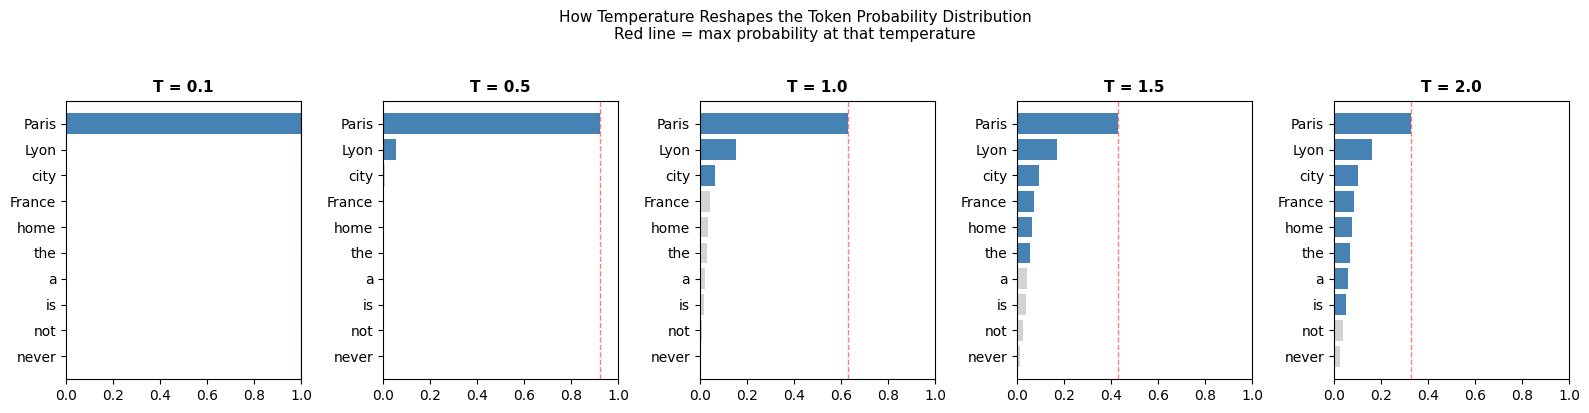

Observation:
  T=0.1 : almost all probability on "Paris" — near-deterministic
  T=1.0 : original distribution — moderate diversity
  T=2.0 : probability spread across many tokens — high diversity


In [5]:
# ---------------------------------------------------------------
# Visualize how temperature changes the token distribution
# ---------------------------------------------------------------

import torch
import torch.nn.functional as F

# Simulated logits for 10 vocabulary tokens
logits = torch.tensor([3.2, 1.8, 0.9, 0.5, 0.3, 0.1, -0.2, -0.5, -1.0, -2.0])
vocab  = ['Paris', 'Lyon', 'city', 'France', 'home', 'the', 'a', 'is', 'not', 'never']

temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, len(temperatures), figsize=(16, 4), sharey=False)

for ax, T in zip(axes, temperatures):
    probs = F.softmax(logits / T, dim=0).numpy()
    colors = ['steelblue' if p > 0.05 else 'lightgray' for p in probs]
    ax.barh(vocab[::-1], probs[::-1], color=colors[::-1])
    ax.set_title(f'T = {T}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(x=probs.max(), color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle(
    'How Temperature Reshapes the Token Probability Distribution\n'
    'Red line = max probability at that temperature',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print('Observation:')
print('  T=0.1 : almost all probability on "Paris" — near-deterministic')
print('  T=1.0 : original distribution — moderate diversity')
print('  T=2.0 : probability spread across many tokens — high diversity')

In [6]:
# ---------------------------------------------------------------
# Generate text at different temperatures using GPT-2
# No API key needed
# ---------------------------------------------------------------

from transformers import pipeline

generator = pipeline('text-generation', model='gpt2', device=-1)

prompt = 'The future of artificial intelligence is'

print(f'Prompt: "{prompt}"')
print('=' * 65)

temperature_configs = [
    {'temperature': 0.1,  'label': 'T=0.1  (deterministic / factual)'},
    {'temperature': 0.7,  'label': 'T=0.7  (balanced)'},
    {'temperature': 1.4,  'label': 'T=1.4  (creative / diverse)'},
]

for config in temperature_configs:
    outputs = generator(
        prompt,
        max_new_tokens = 60,
        temperature    = config['temperature'],
        do_sample      = True,
        top_p          = 0.95,
        num_return_sequences = 1,
        pad_token_id   = 50256,   # GPT-2 EOS token
    )
    generated = outputs[0]['generated_text']
    new_text   = generated[len(prompt):]

    print(f'\n{config["label"]}')
    print(f'{prompt}[{new_text}]')

Prompt: "The future of artificial intelligence is"

T=0.1  (deterministic / factual)
The future of artificial intelligence is[ uncertain. The future of artificial intelligence is uncertain.

The future of artificial intelligence is uncertain.

The future of artificial intelligence is uncertain.

The future of artificial intelligence is uncertain.

The future of artificial intelligence is uncertain.

The future of artificial intelligence is uncertain.]

T=0.7  (balanced)
The future of artificial intelligence is[ very bright, because it's the next step in advancing science, advancing humanity, advancing the human race, and we're going to have to keep doing that.

It is a very interesting time for humanity. There's tremendous economic opportunity in the world right now. There are many benefits to the]

T=1.4  (creative / diverse)
The future of artificial intelligence is[ an interesting one, but if it is going to grow to become pervasive, we need to take great care when we create it and no

---

## Part 6 — Calling LLM APIs

In practice you rarely run models locally for production use.
You call an API that handles the compute. This is cheaper, faster,
and gives access to models too large to run locally.

### The Chat Format

```
Modern LLM APIs use a messages format:

messages = [
    {'role': 'system',    'content': 'You are a helpful assistant.'},
    {'role': 'user',      'content': 'What is the capital of France?'},
    {'role': 'assistant', 'content': 'The capital of France is Paris.'},
    {'role': 'user',      'content': 'What is its population?'},
]

Roles:
  system     →  persistent instructions that frame the conversation
  user       →  human turn
  assistant  →  model turn (for multi-turn conversations)

The entire conversation history is sent with every API call.
The model has no persistent memory — statefulness is YOUR responsibility.
```

### What the API Returns

```
response.choices[0].message.content   →  the generated text
response.usage.prompt_tokens          →  tokens in your input
response.usage.completion_tokens      →  tokens in the response
response.usage.total_tokens           →  sum — what you are billed for
response.model                        →  exact model version used
response.finish_reason                →  'stop' | 'length' | 'tool_calls'
```

In [ ]:
# ---------------------------------------------------------------
# OpenAI API example
# Requires: pip install openai
# Requires: OPENAI_API_KEY environment variable
# If you don't have a key, skip to the next cell
# ---------------------------------------------------------------

OPENAI_AVAILABLE = bool(os.environ.get('OPENAI_API_KEY'))

if OPENAI_AVAILABLE:
    from openai import OpenAI
    client = OpenAI()

    messages = [
        {
            'role'    : 'system',
            'content' : (
                'You are a concise AI tutor teaching a student on day 11 '
                'of a 30-day AI learning journey. Explain concepts in 2-3 '
                'sentences with one concrete example each.'
            )
        },
        {
            'role'    : 'user',
            'content' : 'What is the difference between a base model and an instruction-tuned model?'
        }
    ]

    response = client.chat.completions.create(
        model       = 'gpt-3.5-turbo',
        messages    = messages,
        temperature = 0.7,
        max_tokens  = 200,
    )

    print('OpenAI API Response')
    print('=' * 55)
    print(response.choices[0].message.content)
    print()
    print('Token Usage')
    print('-' * 40)
    print(f'Prompt tokens     : {response.usage.prompt_tokens}')
    print(f'Completion tokens : {response.usage.completion_tokens}')
    print(f'Total tokens      : {response.usage.total_tokens}')
    cost = response.usage.total_tokens / 1_000_000 * 0.50
    print(f'Estimated cost    : ${cost:.6f}  (at $0.50/1M tokens)')
else:
    print('OPENAI_API_KEY not set. Skipping this cell.')
    print('Set it with: export OPENAI_API_KEY=sk-...')
    print('Or use Google Colab secrets (key icon in left sidebar).')

---

## Day 11 Summary

```
What you learned today:

1.  Training pipeline   →  pretraining → SFT → RLHF/DPO
2.  Next-token prediction → what it actually teaches the model
3.  Scaling laws        →  loss follows power laws with compute
4.  Emergent abilities  →  capabilities that appear at scale
5.  Tokens             →  ~4 chars each, context windows, KV cache
6.  Sampling params    →  temperature, top-k, top-p visualized
7.  API calls          →  messages format, token counting, cost

The key mental model:

  A base LLM is a text completion machine.
  SFT teaches it to answer instead of complete.
  RLHF teaches it what 'good answer' means to humans.
  You interact with the result via the messages API.


```

### Self-Check Questions

Answer these before Day 12:

1. Why does a base model respond to 'What is 2+2?' by generating more questions?
2. What would happen if you set temperature=0 for creative writing?
3. Why does the KV cache exist, and what does it trade off?
4. You have a 128K context window model. Your document is 100K tokens.
   Why might this still be a problem for question answering?
5. What is the difference between top-k and top-p sampling?